In [1]:
import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm

import scanpy as sc
from sklearn.metrics.cluster import *
import seaborn as sns
from matplotlib import pyplot as plt

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, dpi_save=300, facecolor='white')


In [2]:
%%time
pred = pd.read_pickle("./test_mode_pred_prob.p", compression='xz')
# target = pd.read_pickle("./test_target_prob.p", compression='xz')

CPU times: user 38.9 s, sys: 856 ms, total: 39.8 s
Wall time: 39.8 s


In [3]:
anno = pd.read_csv("/media/ggj/Files/mount/NvWA_Final/0_Annotation_Cellcluster/MCA_cellatlas.annotation.20210125.txt", sep='\t', index_col=0, header=0).loc[pred.columns]
d = {j:i for i,j in enumerate(anno.Celltype.unique())}
anno['Idents'] = anno.Celltype.map(lambda x: d.get(x))
anno

,Species,Celltype,Cellcluster,Idents
AdultAdrenalGland_1.AACCTAAGATGGGTAATG,Mouse,Endothelial_Mouse48,Endothelial,0
AdultAdrenalGland_1.AACCTAATCTCTCTCGCA,Mouse,Endothelial_Mouse48,Endothelial,0
AdultAdrenalGland_1.AACCTACAACAATGCGGA,Mouse,Endothelial_Mouse48,Endothelial,0
AdultAdrenalGland_1.AACCTAGATCTTACTTAT,Mouse,Endothelial_Mouse48,Endothelial,0
AdultAdrenalGland_1.AACCTAGCCCTCGGCTGC,Mouse,Endothelial_Mouse48,Endothelial,0
...,...,...,...,...
Testis_1.CAAAGTCCTAGAAAGTAC,Mouse,Stromal_Mouse66,Stromal,97
Testis_1.CCTAGATGCGGATAAGGG,Mouse,Stromal_Mouse66,Stromal,97
Testis_2.AGTCGTGAATTAAAAACG,Mouse,Stromal_Mouse66,Stromal,97
Testis_2.GTTGCCTATTGTATACAG,Mouse,Stromal_Mouse66,Stromal,97


In [4]:
cell_sel = anno.index.intersection(pred.columns)
gene_sel = pred.index.values

pred_sel = pred[cell_sel]
anno_sel= anno.loc[cell_sel]

/home/ggj/anaconda3/envs/pytorch-cuda/lib/python3.7/site-packages/anndata/_core/anndata.py:1192: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if is_string_dtype(df[key]) and not is_categorical(df[key])
... storing 'Species' as categorical
... storing 'Celltype' as categorical
... storing 'Cellcluster' as categorical


normalizing counts per cell
    finished (0:00:03)


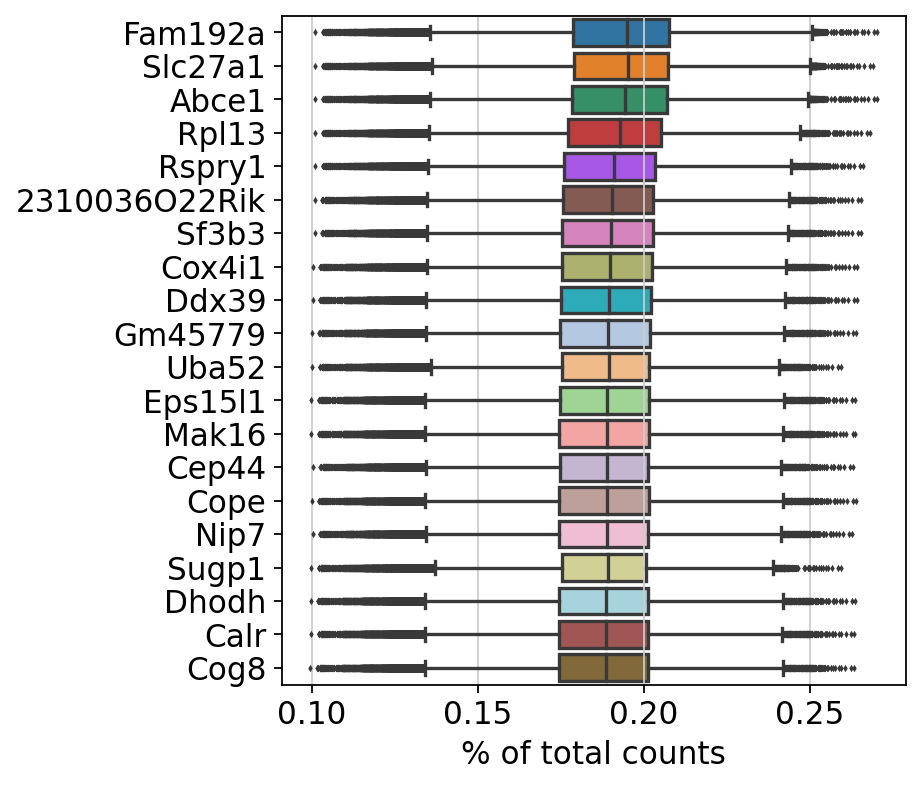

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:06)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


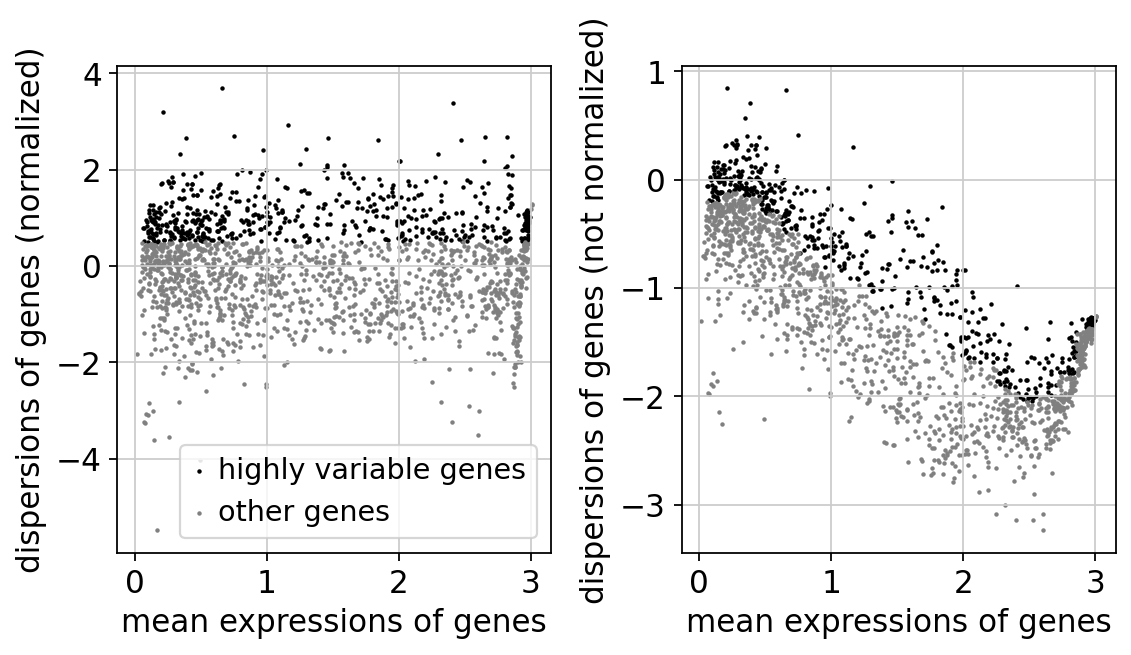

/home/ggj/anaconda3/envs/pytorch-cuda/lib/python3.7/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):
/home/ggj/anaconda3/envs/pytorch-cuda/lib/python3.7/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/home/ggj/anaconda3/envs/pytorch-cuda/lib/python3.7/site-packages/scanpy/preprocessing/_simple.py:848: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:07)
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:38)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 116 clusters and added
    'louvain', the cluster labels (adata.obs, categorical) (0:00:15)
computing tSNE
    using 'X_pca' with n_pcs = 40
    using the 'MulticoreTSNE' package by Ulyanov (2017)
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm) (0:25:57)


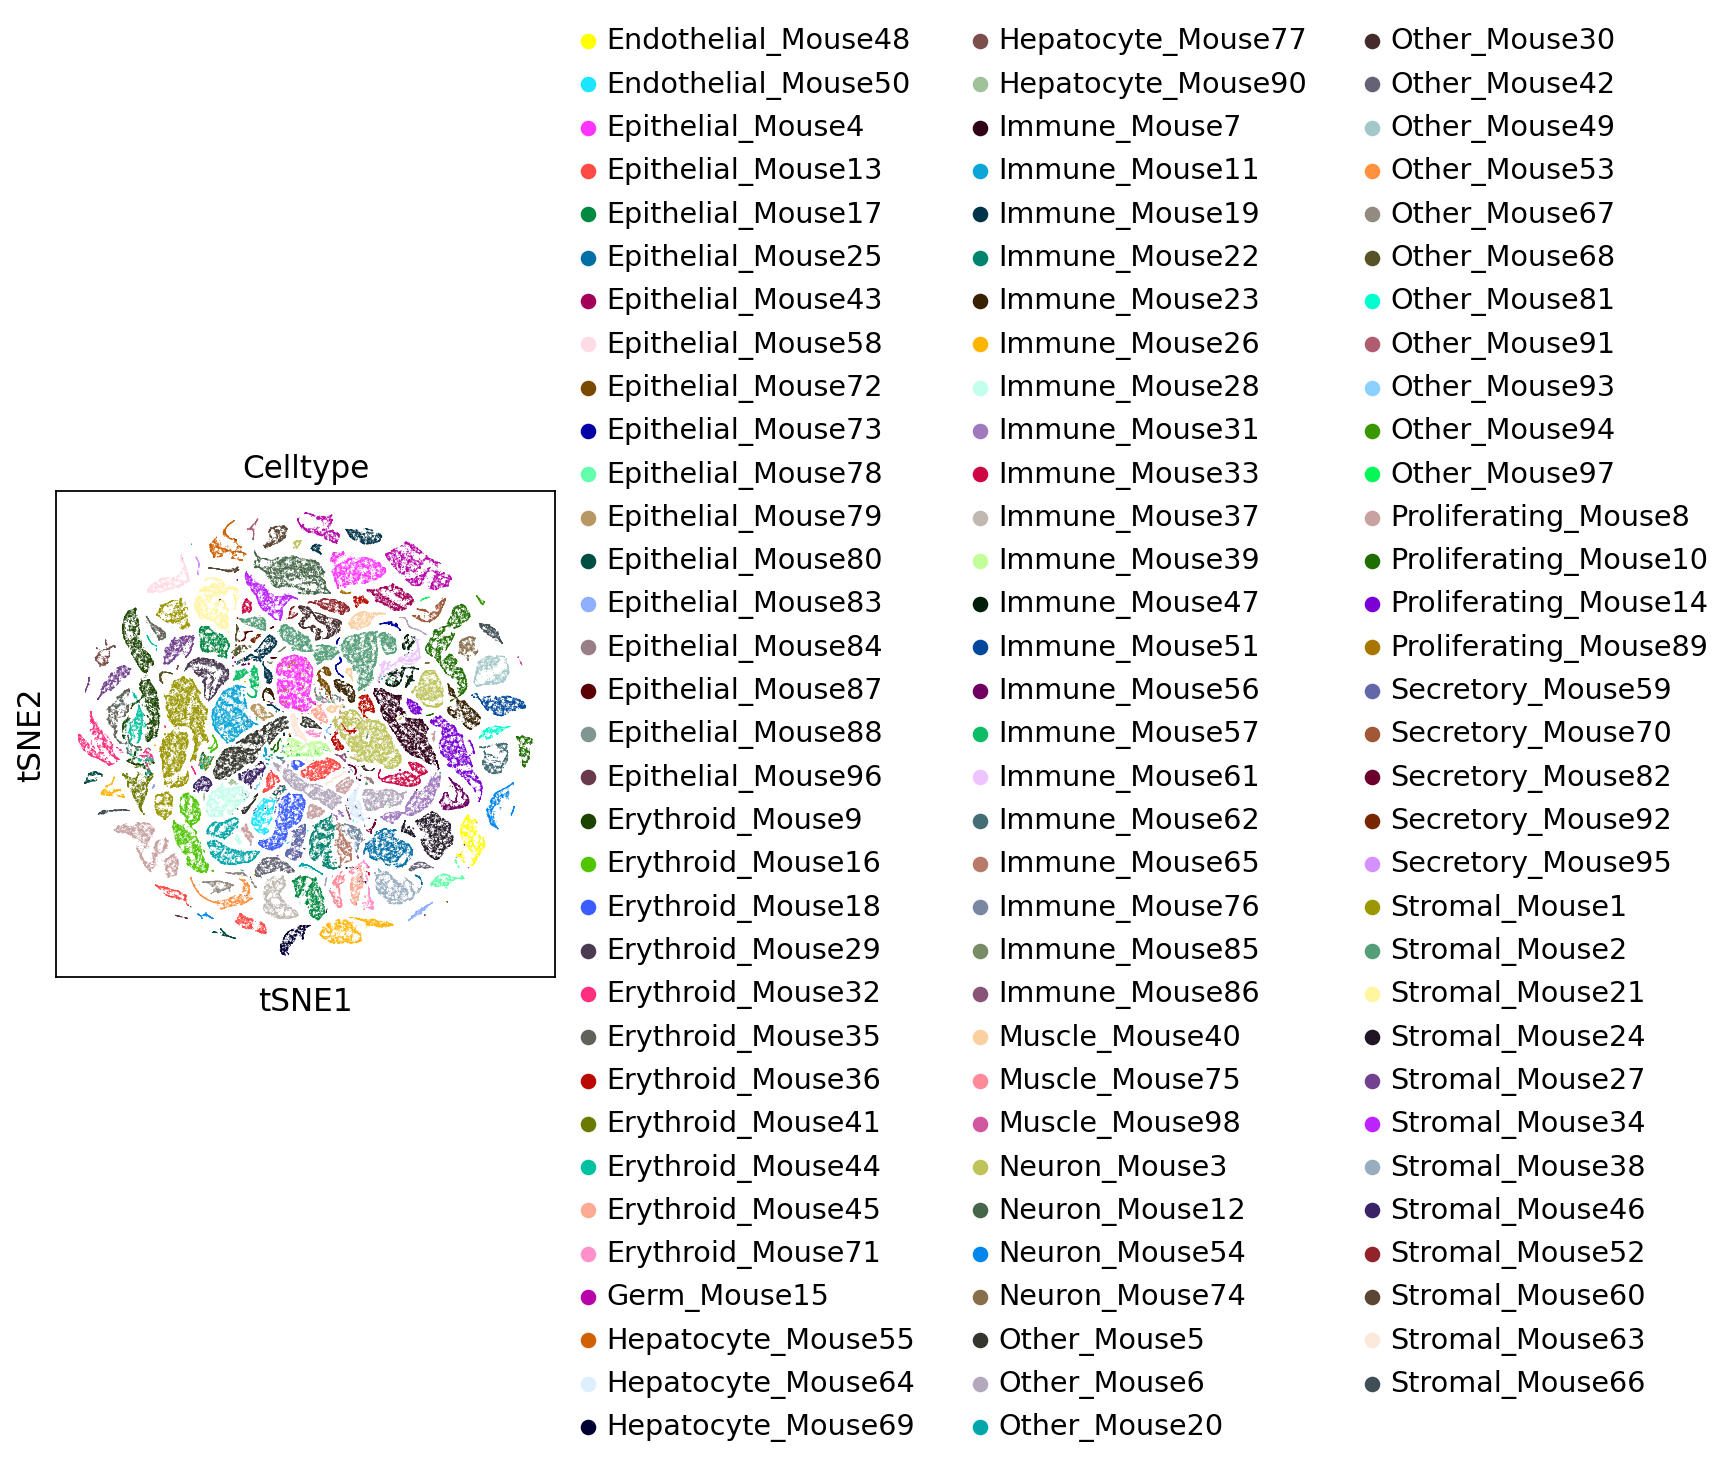

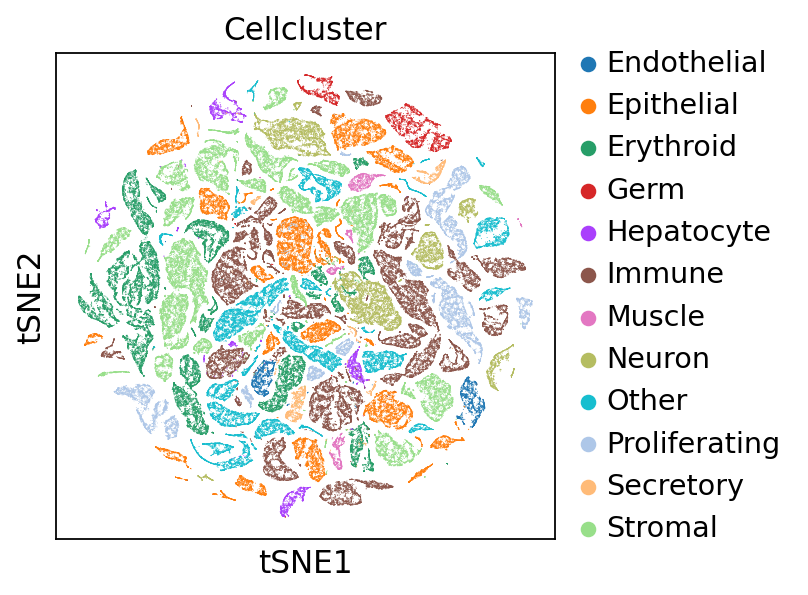

0.9478492042562843


In [5]:
## pred
adata = sc.AnnData(pred.T.copy())
adata.obs = anno
adata.strings_to_categoricals()

sc.pl.highest_expr_genes(adata, n_top=20, save='.pred')
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)
adata.raw = adata
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.louvain(adata, resolution=1)
sc.tl.tsne(adata, n_pcs=40)

sc.pl.tsne(adata, color=['Celltype'], save=".pred.Celltype")
sc.pl.tsne(adata, color=['Cellcluster'], save=".pred.Cellcluster")

adata.write("./test_pred.h5ad", compression=True)

ami = adjusted_mutual_info_score(adata.obs.Idents.values, adata.obs.louvain.values)
print(ami)
